# Proyecto Pipeline Automatizado con Modelo Detector de IA sobre Código Vulnerable

## Descarga de Datasets y Normalización de Dataset

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn lime shap kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, re, glob, warnings
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

### Dataset Kaggle

[URL Dataset](https://www.kaggle.com/datasets/jiscecseaiml/vulnerability-fix-dataset)

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download('jiscecseaiml/vulnerability-fix-dataset')
print(path)

kaggle_dataset = pd.read_csv(f'{path}/vulnerability_fix_dataset.csv')

Using Colab cache for faster access to the 'vulnerability-fix-dataset' dataset.
/kaggle/input/vulnerability-fix-dataset


In [ ]:
# Debug
kaggle_dataset.head()
kaggle_dataset.shape

(35000, 3)

### Dataset HuggingFace

[URL Dataset](https://huggingface.co/datasets/nuojohnchen/devign-processed)

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

hf_dataset_raw = load_dataset('nuojohnchen/devign-processed')

hf_dataset = hf_dataset_raw['train'].to_pandas()

In [ ]:
# Debug
hf_dataset.head()
hf_dataset.shape

(21854, 3)

### Dataset Unificado

In [ ]:
rows = []

# Kaggle
for _, row in kaggle_dataset.iterrows():
    rows.append({
        "function": row["vulnerable_code"],
        "is_vulnerable": True
    })

    rows.append({
        "function": row["fixed_code"],
        "is_vulnerable": False
    })

# Hugging Face
for _, row in hf_dataset.iterrows():
    rows.append({
        "function": row["func1"],
        "is_vulnerable": row["label"] == 0
    })

full_dataset = pd.DataFrame(rows)

In [ ]:
# Debug
full_dataset.shape

full_dataset.value_counts('is_vulnerable')

,count
is_vulnerable,
True,46836
False,45018


## Partición train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    full_dataset["function"], full_dataset["is_vulnerable"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=full_dataset["is_vulnerable"]
)

## Entrenamiento del Modelo

### Sanitización

In [ ]:
TOKEN_PATTERN = r"(?u)\b\w+\b|==|!=|<=|>=|&&|\|\||[{}()\[\];=+\-*/<>.'\"]"

vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=TOKEN_PATTERN,
    ngram_range=(1, 2),
    min_df=1,
    max_features=20000,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
analyzer = vectorizer.build_analyzer()

analyzer(X_train.iloc[1])

['string',
 'userinput',
 '=',
 '"',
 "'",
 ';',
 'drop',
 'table',
 'users',
 ';',
 '-',
 '-',
 '"',
 ';',
 '/',
 '/',
 'create',
 'a',
 'preparedstatement',
 'with',
 'parameterized',
 'query',
 'string',
 'query',
 '=',
 '"',
 'select',
 '*',
 'from',
 'users',
 'where',
 'username',
 '=',
 '"',
 ';',
 'preparedstatement',
 'statement',
 '=',
 'connection',
 '.',
 'preparestatement',
 '(',
 'query',
 ')',
 ';',
 'statement',
 '.',
 'setstring',
 '(',
 '1',
 'userinput',
 ')',
 ';',
 '/',
 '/',
 'execute',
 'the',
 'query',
 'using',
 'the',
 'preparedstatement',
 'resultset',
 'resultset',
 '=',
 'statement',
 '.',
 'executequery',
 '(',
 ')',
 ';',
 '/',
 '/',
 'process',
 'the',
 'resultset',
 'as',
 'needed',
 'string userinput',
 'userinput =',
 '= "',
 '" \'',
 "' ;",
 '; drop',
 'drop table',
 'table users',
 'users ;',
 '; -',
 '- -',
 '- "',
 '" ;',
 '; /',
 '/ /',
 '/ create',
 'create a',
 'a preparedstatement',
 'preparedstatement with',
 'with parameterized',
 'parameter

### Entrenamiento

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    random_state=RANDOM_STATE,
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Evaluación del Modelo

Accuracy: 0.9070719

              precision    recall  f1-score   support

       False     0.9096    0.8999    0.9047     11255
        True     0.9047    0.9140    0.9093     11709

    accuracy                         0.9071     22964
   macro avg     0.9071    0.9069    0.9070     22964
weighted avg     0.9071    0.9071    0.9071     22964



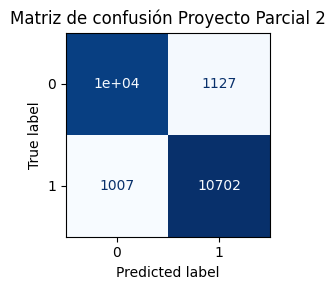

In [ ]:
y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.7f}")
print()
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión Proyecto Parcial 2")
plt.tight_layout()
plt.show()

## Descarga del Modelo

In [ ]:
joblib.dump({
    "vectorizer": vectorizer,
    "model": model
}, "vulnerability_detector.pkl")

['vulnerability_detector.pkl']

## Prueba de código individual

In [ ]:
# Carga de modelo
import joblib

saved = joblib.load("vulnerability_detector.pkl")

vectorizer = saved["vectorizer"]
model = saved["model"]

In [ ]:
code = """
cursor.execute(
    "SELECT * FROM users WHERE username='" + user + "'"
)
"""

X = vectorizer.transform([code])

prediction = model.predict(X)[0]
probability = model.predict_proba(X)[0]

print("Vulnerable:", prediction)
print("Probabilidades:", probability)

Vulnerable: True
Probabilidades: [0.00472684 0.99527316]
